# EDA - Waste Classification Dataset

Notebook ini adalah adaptasi EDA untuk dataset waste classification.

Notebook ini otomatis mendeteksi dua kemungkinan struktur folder:
- **Dengan split**: `TRAIN/`, `TEST/` masing-masing berisi subfolder kelas (mis. `O`/`R` atau `organic`/`recyclable`).
- **Tanpa split** (seperti dataset lokal kamu saat ini): folder kelas langsung di root, mis. `waste_dataset/organic`, `waste_dataset/recyclable`.

Kalau tidak ada split TRAIN/TEST, seluruh analisis dijalankan di atas seluruh dataset, dan sel yang butuh perbandingan train-vs-test otomatis di-skip.

In [1]:
import os
from pathlib import Path

# --- Kandidat lokasi dataset ---
# Kalau auto-detect gagal, isi manual di sini, contoh:
# MANUAL_DATA_DIR = r"C:\Users\HP\Documents\BDC 2026\satria-data-bdc-2026-1\Waste Classification Dataset\waste_dataset"
MANUAL_DATA_DIR = None

DATASET_KEYWORD = "waste"          # dipakai saat mencari folder root secara otomatis
TRAIN_NAME_CANDIDATES = ["TRAIN", "train"]
TEST_NAME_CANDIDATES = ["TEST", "test"]

def _subdir_names(d: Path):
    try:
        return {p.name: p for p in d.iterdir() if p.is_dir()}
    except (PermissionError, FileNotFoundError):
        return {}

def _has_split(d: Path):
    names = _subdir_names(d)
    lower_names = {n.lower(): n for n in names}
    has_train = any(t.lower() in lower_names for t in TRAIN_NAME_CANDIDATES)
    has_test = any(t.lower() in lower_names for t in TEST_NAME_CANDIDATES)
    return has_train and has_test

def _detect_class_folders(d: Path):
    """Folder kelas = semua subfolder langsung di d yang berisi minimal 1 file gambar."""
    img_ext = {".jpg", ".jpeg", ".png", ".bmp", ".gif", ".webp"}
    class_dirs = []
    for name, p in sorted(_subdir_names(d).items()):
        has_image = any(f.suffix.lower() in img_ext for f in p.glob("*.*"))
        if has_image:
            class_dirs.append(name)
    return class_dirs

def find_dataset_root(start_dir=None, keyword=DATASET_KEYWORD):
    start_dir = Path(start_dir) if start_dir else Path.cwd()

    # 1) Path manual (kalau diisi)
    if MANUAL_DATA_DIR:
        p = Path(MANUAL_DATA_DIR)
        if p.exists():
            return p

    # 2) Naik ke atas cari nama folder yang mengandung keyword,
    #    lalu cek apakah folder itu (atau salah satu subfoldernya) valid sebagai dataset
    check_dir = start_dir
    while check_dir != check_dir.parent:
        if keyword in check_dir.name.lower():
            if _has_split(check_dir) or _detect_class_folders(check_dir):
                return check_dir
            for sub in check_dir.rglob("*"):
                if sub.is_dir() and (_has_split(sub) or _detect_class_folders(sub)):
                    return sub
        check_dir = check_dir.parent

    # 3) Turun dari start_dir cari folder yang valid
    if _has_split(start_dir) or _detect_class_folders(start_dir):
        return start_dir
    for sub in start_dir.rglob("*"):
        if sub.is_dir() and (_has_split(sub) or _detect_class_folders(sub)):
            return sub

    # 4) Fallback lokasi umum Kaggle
    for guess in [Path("/kaggle/input/waste-classification-data/DATASET"),
                  Path("/kaggle/input/waste-classification-data")]:
        if guess.exists():
            return guess

    return start_dir

data_dir = find_dataset_root()
HAS_SPLIT = _has_split(data_dir)

if HAS_SPLIT:
    def get_split_dir(base_dir, candidates):
        lower_map = {p.name.lower(): p for p in base_dir.iterdir() if p.is_dir()}
        for name in candidates:
            if name.lower() in lower_map:
                return lower_map[name.lower()]
        raise FileNotFoundError(f"Tidak ketemu folder split dari {candidates} di {base_dir}")

    TRAIN_DIR = get_split_dir(data_dir, TRAIN_NAME_CANDIDATES)
    TEST_DIR = get_split_dir(data_dir, TEST_NAME_CANDIDATES)
    CLASS_FOLDERS = _detect_class_folders(TRAIN_DIR)
else:
    # Tidak ada split: seluruh dataset dianggap satu pool, folder kelas langsung di data_dir
    TRAIN_DIR = data_dir
    TEST_DIR = None
    CLASS_FOLDERS = _detect_class_folders(data_dir)

# Mapping label tampilan (huruf awal kapital), fallback ke nama asli kalau tidak dikenal
_KNOWN_LABELS = {"o": "Organic", "r": "Recyclable", "organic": "Organic", "recyclable": "Recyclable",
                 "e": "Electronic", "electronic": "Electronic"}
CLASS_LABELS = {c: _KNOWN_LABELS.get(c.lower(), c) for c in CLASS_FOLDERS}

print(f"Dataset root terdeteksi : {data_dir}")
print(f"Ada split TRAIN/TEST?   : {HAS_SPLIT}")
print(f"TRAIN_DIR (atau pool)   : {TRAIN_DIR}")
print(f"TEST_DIR                : {TEST_DIR}")
print(f"CLASS_FOLDERS           : {CLASS_FOLDERS}")
print(f"CLASS_LABELS            : {CLASS_LABELS}")

if not CLASS_FOLDERS:
    raise RuntimeError(
        "Tidak ada folder kelas (berisi gambar) yang terdeteksi. "
        "Isi MANUAL_DATA_DIR di atas dengan path lengkap ke folder dataset kamu."
    )

Dataset root terdeteksi : c:\Users\HP\Documents\BDC 2026\satria-data-bdc-2026-1\Waste Classification Dataset\waste_dataset
Ada split TRAIN/TEST?   : False
TRAIN_DIR (atau pool)   : c:\Users\HP\Documents\BDC 2026\satria-data-bdc-2026-1\Waste Classification Dataset\waste_dataset
TEST_DIR                : None
CLASS_FOLDERS           : ['organic', 'recyclable']
CLASS_LABELS            : {'organic': 'Organic', 'recyclable': 'Recyclable'}


In [2]:
# Cell 2 (Print the directory structure in a tree-like format)
def print_tree(root_dir, max_files_per_folder=3, prefix=""):
    root_dir = Path(root_dir)
    entries = sorted(root_dir.iterdir(), key=lambda x: (x.is_file(), x.name))

    for i, entry in enumerate(entries):
        connector = "\u2514\u2500\u2500 " if i == len(entries) - 1 else "\u251c\u2500\u2500 "
        if entry.is_dir():
            n_files = len(list(entry.glob("*")))
            print(f"{prefix}{connector}{entry.name}/  ({n_files} item)")
            extension = "    " if i == len(entries) - 1 else "\u2502   "
            print_tree(entry, max_files_per_folder, prefix + extension)
        else:
            print(f"{prefix}{connector}{entry.name}")

In [3]:
# Cell 3 (Summarize the structure of the dataset)
def summarize_structure(data_dir):
    data_dir = Path(data_dir)
    print(f"Struktur folder: {data_dir}\n")
    print(data_dir.name + "/")

    for split_dir in sorted(data_dir.iterdir()):
        if not split_dir.is_dir():
            continue
        print(f"\u251c\u2500\u2500 {split_dir.name}/")
        subdirs = [d for d in split_dir.iterdir() if d.is_dir()]

        if subdirs:
            for cls_dir in sorted(subdirs):
                n_files = len(list(cls_dir.glob("*.*")))
                print(f"\u2502   \u251c\u2500\u2500 {cls_dir.name}/  -> {n_files} file")
        else:
            files = list(split_dir.glob("*.*"))
            print(f"\u2502   -> {len(files)} file (tanpa subfolder/label)")
            if files:
                print(f"\u2502   -> contoh nama file: {[f.name for f in files[:5]]}")

In [4]:
# Execution
summarize_structure(data_dir)
print_tree(data_dir)

Struktur folder: c:\Users\HP\Documents\BDC 2026\satria-data-bdc-2026-1\Waste Classification Dataset\waste_dataset

waste_dataset/
├── organic/
│   -> 13880 file (tanpa subfolder/label)
│   -> contoh nama file: ['organic_000001_photo.jpg', 'organic_000002_photo.jpg', 'organic_000003_photo.jpg', 'organic_000004_photo.jpg', 'organic_000005_photo.jpg']
├── recyclable/
│   -> 10825 file (tanpa subfolder/label)
│   -> contoh nama file: ['recyclable_000001_photo.jpg', 'recyclable_000002_photo.jpg', 'recyclable_000003_photo.jpg', 'recyclable_000004_photo.jpg', 'recyclable_000005_photo.jpg']
├── organic/  (13880 item)
│   ├── organic_000001_photo.jpg
│   ├── organic_000002_photo.jpg
│   ├── organic_000003_photo.jpg
│   ├── organic_000004_photo.jpg
│   ├── organic_000005_photo.jpg
│   ├── organic_000006_photo.jpg
│   ├── organic_000007_photo.jpg
│   ├── organic_000008_photo.jpg
│   ├── organic_000009_photo.jpg
│   ├── organic_000010_photo.jpg
│   ├── organic_000011_photo.jpg
│   ├── organic_0000

In [5]:
from PIL import Image

def find_corrupt_images(folder_path):
    """
    Scan semua file gambar di folder_path (termasuk subfolder),
    return dict berisi path file yang corrupt beserta pesan error-nya.
    """
    corrupt_files = {}
    all_files = list(Path(folder_path).rglob("*.*"))

    for file_path in all_files:
        try:
            with Image.open(file_path) as img:
                img.verify()
        except Exception as e:
            corrupt_files[str(file_path)] = str(e)

    return corrupt_files, len(all_files)

if HAS_SPLIT:
    train_corrupt, train_total = find_corrupt_images(TRAIN_DIR)
    print(f"[TRAIN] Total file discan: {train_total}")
    print(f"[TRAIN] Jumlah file corrupt: {len(train_corrupt)}")
    if train_corrupt:
        print("[TRAIN] Daftar file corrupt:")
        for path, err in train_corrupt.items():
            print(f"  - {path} -> {err}")

    test_corrupt, test_total = find_corrupt_images(TEST_DIR)
    print(f"\n[TEST] Total file discan: {test_total}")
    print(f"[TEST] Jumlah file corrupt: {len(test_corrupt)}")
    if test_corrupt:
        print("[TEST] Daftar file corrupt:")
        for path, err in test_corrupt.items():
            print(f"  - {path} -> {err}")
else:
    all_corrupt, all_total = find_corrupt_images(data_dir)
    print(f"[DATASET] Total file discan: {all_total}")
    print(f"[DATASET] Jumlah file corrupt: {len(all_corrupt)}")
    if all_corrupt:
        print("[DATASET] Daftar file corrupt:")
        for path, err in all_corrupt.items():
            print(f"  - {path} -> {err}")

[DATASET] Total file discan: 24710
[DATASET] Jumlah file corrupt: 5
[DATASET] Daftar file corrupt:
  - c:\Users\HP\Documents\BDC 2026\satria-data-bdc-2026-1\Waste Classification Dataset\waste_dataset\coba.ipynb -> cannot identify image file 'c:\\Users\\HP\\Documents\\BDC 2026\\satria-data-bdc-2026-1\\Waste Classification Dataset\\waste_dataset\\coba.ipynb'
  - c:\Users\HP\Documents\BDC 2026\satria-data-bdc-2026-1\Waste Classification Dataset\waste_dataset\waste_classification_eda.ipynb -> cannot identify image file 'c:\\Users\\HP\\Documents\\BDC 2026\\satria-data-bdc-2026-1\\Waste Classification Dataset\\waste_dataset\\waste_classification_eda.ipynb'
  - c:\Users\HP\Documents\BDC 2026\satria-data-bdc-2026-1\Waste Classification Dataset\waste_dataset\waste_dataset_augmentation.ipynb -> cannot identify image file 'c:\\Users\\HP\\Documents\\BDC 2026\\satria-data-bdc-2026-1\\Waste Classification Dataset\\waste_dataset\\waste_dataset_augmentation.ipynb'
  - c:\Users\HP\Documents\BDC 2026\sa

In [6]:
import hashlib

def compute_file_hash(file_path):
    """Hitung MD5 hash dari isi file (byte-level, exact match)."""
    hasher = hashlib.md5()
    with open(file_path, 'rb') as f:
        hasher.update(f.read())
    return hasher.hexdigest()

if HAS_SPLIT:
    test_hashes = {}
    test_files = list(TEST_DIR.rglob("*.*"))
    for file_path in test_files:
        test_hashes[compute_file_hash(file_path)] = str(file_path)
    print(f"Total unique hash di test: {len(test_hashes)} (dari {len(test_files)} file)")

    train_test_duplicates = {}
    train_files = list(TRAIN_DIR.rglob("*.*"))
    for file_path in train_files:
        file_hash = compute_file_hash(file_path)
        if file_hash in test_hashes:
            train_test_duplicates[str(file_path)] = test_hashes[file_hash]

    print(f"\nJumlah file train yang identik (exact) dengan file test: {len(train_test_duplicates)}")
    if train_test_duplicates:
        print("Daftar pasangan duplikat (train -> test):")
        for train_path, test_path in train_test_duplicates.items():
            print(f"  - {train_path}  <->  {test_path}")
else:
    print("Dataset tidak punya split TRAIN/TEST terpisah, jadi cek duplikat train-vs-test di-skip.")
    print("Kalau kamu nanti bikin train_test_split sendiri, jalankan ulang cell ini setelah split dibuat.")

Dataset tidak punya split TRAIN/TEST terpisah, jadi cek duplikat train-vs-test di-skip.
Kalau kamu nanti bikin train_test_split sendiri, jalankan ulang cell ini setelah split dibuat.


In [7]:
import numpy as np
from PIL import Image
import random
import pandas as pd

random.seed(42)  # reproducibility

def sample_files_per_class(base_dir, class_folders, n_samples=500):
    """Ambil sample acak file per kelas."""
    samples = {}
    for cls in class_folders:
        files = list((base_dir / cls).rglob("*.*"))
        n = min(n_samples, len(files))
        samples[cls] = random.sample(files, n)
        print(f"{cls} ({CLASS_LABELS.get(cls, cls)}): sampling {n} dari {len(files)} file")
    return samples

sampled_files = sample_files_per_class(TRAIN_DIR, CLASS_FOLDERS, n_samples=500)

results = []
corrupt_files = []

for cls, files in sampled_files.items():
    for f in files:
        try:
            img = Image.open(f)
            img.verify()
            img = Image.open(f)
            mode = img.mode

            img_rgb = img.convert("RGB")
            arr = np.array(img_rgb)

            mean_r, mean_g, mean_b = arr[:,:,0].mean(), arr[:,:,1].mean(), arr[:,:,2].mean()
            brightness = arr.mean()

            results.append({
                "class": cls, "file": str(f), "mode": mode,
                "mean_r": mean_r, "mean_g": mean_g, "mean_b": mean_b, "brightness": brightness
            })
        except Exception as e:
            corrupt_files.append((str(f), str(e)))

print(f"\nTotal file berhasil diproses: {len(results)}")
print(f"Total file corrupt/gagal dibuka: {len(corrupt_files)}")
if corrupt_files:
    print("Contoh file bermasalah:")
    for fp, err in corrupt_files[:10]:
        print(f"  - {fp}: {err}")

df_results = pd.DataFrame(results)
print("\nDistribusi mode gambar per kelas:")
print(df_results.groupby("class")["mode"].value_counts())

print("\nRata-rata channel warna & brightness per kelas:")
print(df_results.groupby("class")[["mean_r", "mean_g", "mean_b", "brightness"]].agg(["mean", "std"]))

organic (Organic): sampling 500 dari 13880 file
recyclable (Recyclable): sampling 500 dari 10825 file

Total file berhasil diproses: 1000
Total file corrupt/gagal dibuka: 0

Distribusi mode gambar per kelas:
class       mode
organic     RGB     500
recyclable  RGB     500
Name: count, dtype: int64

Rata-rata channel warna & brightness per kelas:
                mean_r                 mean_g                 mean_b  \
                  mean        std        mean        std        mean   
class                                                                  
organic     163.780114  47.461795  145.788605  46.164806  112.170554   
recyclable  186.469394  48.763591  180.448547  49.374158  174.631349   

                       brightness             
                  std        mean        std  
class                                         
organic     51.784979  140.579758  45.552027  
recyclable  52.354947  180.516430  48.435365  


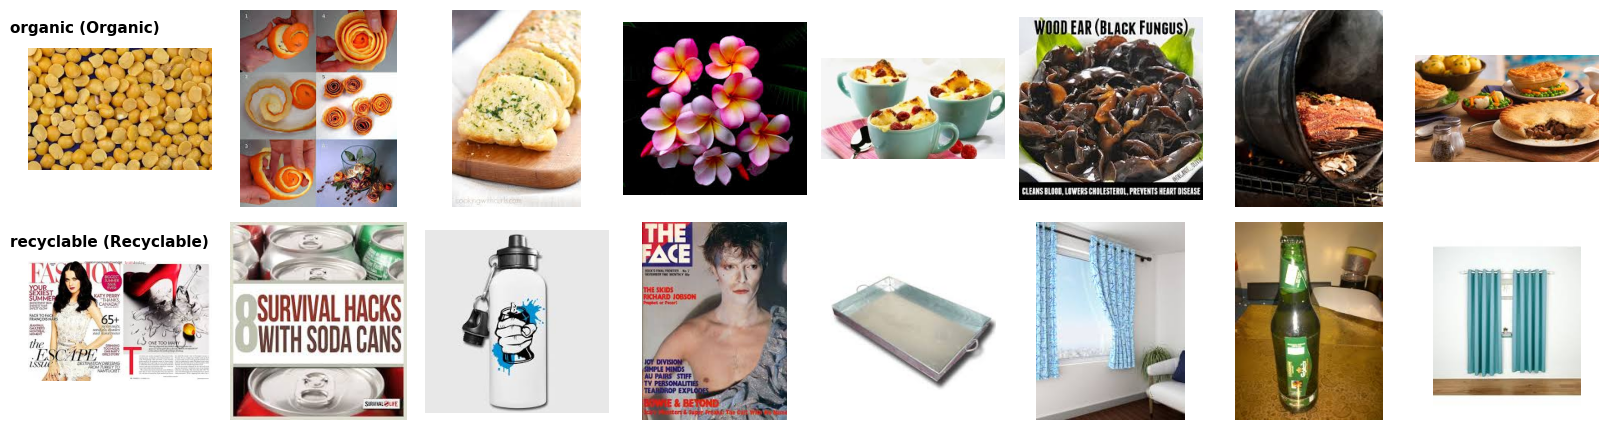

In [8]:
import matplotlib.pyplot as plt

def show_sample_grid(sampled_files, class_folders, n_per_class=8):
    fig, axes = plt.subplots(len(class_folders), n_per_class, figsize=(n_per_class * 2, len(class_folders) * 2.2))
    if len(class_folders) == 1:
        axes = axes.reshape(1, -1)

    for row, cls in enumerate(class_folders):
        files_to_show = random.sample(sampled_files[cls], n_per_class)
        for col, f in enumerate(files_to_show):
            img = Image.open(f).convert("RGB")
            ax = axes[row, col]
            ax.imshow(img)
            ax.axis("off")
        label = f"{cls} ({CLASS_LABELS.get(cls, cls)})"
        axes[row, 0].set_title(label, loc="left", fontsize=11, fontweight="bold", x=-0.1, y=1.05)

    plt.tight_layout()
    plt.show()

show_sample_grid(sampled_files, CLASS_FOLDERS, n_per_class=8)

Statistik background variance per kelas:
            count         mean          std  min         25%          50%  \
class                                                                       
organic     500.0  1872.391014  1732.199353  0.0  409.277241  1512.174698   
recyclable  500.0  1284.237232  1799.430505  0.0    0.877214   562.532226   

                    75%           max  
class                                  
organic     2771.530505  10225.376778  
recyclable  1924.391483  11706.931779  

Proporsi gambar dengan background polos (variance < threshold) per kelas:
class
organic       0.154
recyclable    0.352
Name: is_plain_bg, dtype: float64


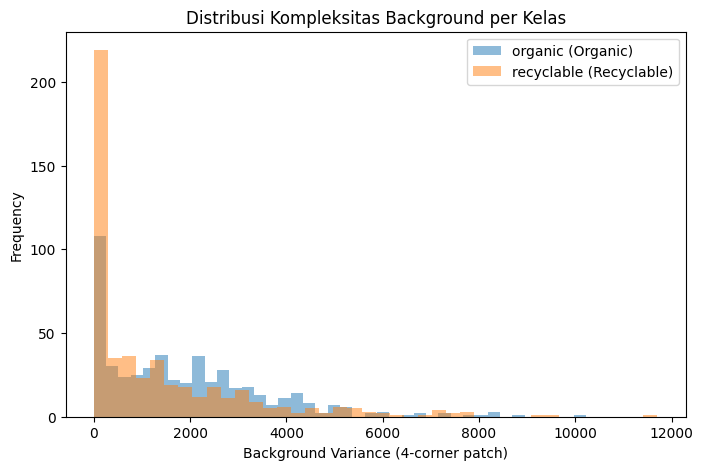

In [9]:
import numpy as np

def compute_background_complexity(img, patch_size=30):
    arr = np.array(img)
    h, w, _ = arr.shape
    p = patch_size
    corners = [arr[0:p, 0:p], arr[0:p, w-p:w], arr[h-p:h, 0:p], arr[h-p:h, w-p:w]]
    variances = [c.var() for c in corners]
    return np.mean(variances)

bg_results = []
for cls, files in sampled_files.items():
    for f in files:
        try:
            img = Image.open(f).convert("RGB")
            bg_var = compute_background_complexity(img)
            bg_results.append({"class": cls, "file": str(f), "bg_variance": bg_var})
        except Exception:
            pass

df_bg = pd.DataFrame(bg_results)
print("Statistik background variance per kelas:")
print(df_bg.groupby("class")["bg_variance"].describe())

threshold = 50  # placeholder, sesuaikan setelah lihat output describe() di atas
df_bg["is_plain_bg"] = df_bg["bg_variance"] < threshold
print("\nProporsi gambar dengan background polos (variance < threshold) per kelas:")
print(df_bg.groupby("class")["is_plain_bg"].mean())

fig, ax = plt.subplots(figsize=(8, 5))
for cls in CLASS_FOLDERS:
    subset = df_bg[df_bg["class"] == cls]["bg_variance"]
    ax.hist(subset, bins=40, alpha=0.5, label=f"{cls} ({CLASS_LABELS.get(cls, cls)})")
ax.set_xlabel("Background Variance (4-corner patch)")
ax.set_ylabel("Frequency")
ax.set_title("Distribusi Kompleksitas Background per Kelas")
ax.legend()
plt.show()

In [10]:
dim_results = []
for cls, files in sampled_files.items():
    for f in files:
        try:
            with Image.open(f) as img:
                w, h = img.size
                dim_results.append({
                    "class": cls, "file": str(f), "width": w, "height": h,
                    "aspect_ratio": round(w / h, 3),
                    "orientation": "square" if abs(w - h) <= 5 else ("landscape" if w > h else "portrait")
                })
        except Exception:
            pass

df_dim = pd.DataFrame(dim_results)
print("=== Statistik Width & Height per Kelas ===")
print(df_dim.groupby("class")[["width", "height"]].describe())
print("\n=== Statistik Aspect Ratio per Kelas ===")
print(df_dim.groupby("class")["aspect_ratio"].describe())
print("\n=== Distribusi Orientasi per Kelas (proporsi) ===")
print(pd.crosstab(df_dim["class"], df_dim["orientation"], normalize="index").round(3))

=== Statistik Width & Height per Kelas ===
            width                                                         \
            count     mean        std   min    25%    50%     75%    max   
class                                                                      
organic     500.0  262.226  45.888325  96.0  225.0  264.5  282.25  535.0   
recyclable  500.0  241.852  43.957327  86.0  225.0  225.0  268.25  486.0   

           height                                                           
            count     mean        std    min     25%    50%     75%    max  
class                                                                       
organic     500.0  196.484  33.406252   94.0  178.00  189.5  224.25  301.0  
recyclable  500.0  211.688  32.963918  104.0  187.75  225.0  225.00  318.0  

=== Statistik Aspect Ratio per Kelas ===
            count      mean       std    min  25%    50%    75%    max
class                                                                 
organic

In [11]:
# Cek apakah ada ukuran gambar yang muncul berkali-kali secara mencurigakan per kelas
for cls in CLASS_FOLDERS:
    subset = df_dim[df_dim["class"] == cls]
    size_counts = subset.groupby(["width", "height"]).size().sort_values(ascending=False)
    top_size = size_counts.index[0]
    top_count = size_counts.iloc[0]
    print(f"[{cls} - {CLASS_LABELS.get(cls, cls)}] ukuran paling umum: {top_size[0]}x{top_size[1]} "
          f"-> {top_count}/{len(subset)} file ({top_count/len(subset):.1%})")

    is_common = (subset["width"] == top_size[0]) & (subset["height"] == top_size[1])
    print(f"  Statistik width untuk file DI LUAR ukuran umum tsb:")
    print(subset[~is_common]["width"].describe())
    print()

[organic - Organic] ukuran paling umum: 275x183 -> 70/500 file (14.0%)
  Statistik width untuk file DI LUAR ukuran umum tsb:
count    430.000000
mean     260.146512
std       49.176950
min       96.000000
25%      225.000000
50%      259.000000
75%      287.750000
max      535.000000
Name: width, dtype: float64

[recyclable - Recyclable] ukuran paling umum: 225x225 -> 148/500 file (29.6%)
  Statistik width untuk file DI LUAR ukuran umum tsb:
count    352.000000
mean     248.937500
std       50.763084
min       86.000000
25%      206.000000
50%      259.000000
75%      275.000000
max      486.000000
Name: width, dtype: float64



=== Statistik Brightness per Kelas ===
            count        mean        std        min         25%         50%  \
class                                                                         
organic     500.0  140.579758  45.552027  24.640956  105.153290  133.428605   
recyclable  500.0  180.516430  48.435365  40.983632  147.106368  188.107848   

                   75%         max  
class                               
organic     176.296528  240.498266  
recyclable  220.616108  252.596089  

=== Rata-rata Channel Warna (R/G/B) per Kelas ===
                r_mean      g_mean      b_mean
class                                         
organic     163.780114  145.788605  112.170554
recyclable  186.469394  180.448547  174.631349


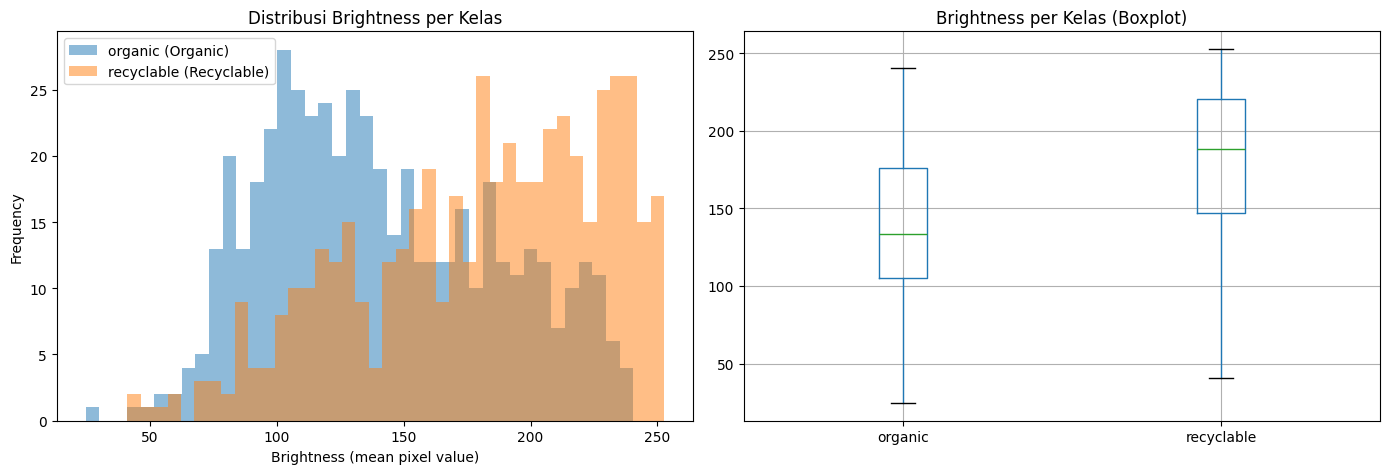

In [12]:
import numpy as np

brightness_results = []
for cls, files in sampled_files.items():
    for f in files:
        try:
            with Image.open(f) as img:
                img_rgb = img.convert("RGB")
                arr = np.array(img_rgb)
                brightness = arr.mean()
                r_mean, g_mean, b_mean = arr[:,:,0].mean(), arr[:,:,1].mean(), arr[:,:,2].mean()
                brightness_results.append({
                    "class": cls, "file": str(f), "brightness": brightness,
                    "r_mean": r_mean, "g_mean": g_mean, "b_mean": b_mean
                })
        except Exception:
            pass

df_brightness = pd.DataFrame(brightness_results)
print("=== Statistik Brightness per Kelas ===")
print(df_brightness.groupby("class")["brightness"].describe())
print("\n=== Rata-rata Channel Warna (R/G/B) per Kelas ===")
print(df_brightness.groupby("class")[["r_mean", "g_mean", "b_mean"]].mean())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for cls in CLASS_FOLDERS:
    subset = df_brightness[df_brightness["class"] == cls]["brightness"]
    axes[0].hist(subset, bins=40, alpha=0.5, label=f"{cls} ({CLASS_LABELS.get(cls, cls)})")
axes[0].set_xlabel("Brightness (mean pixel value)")
axes[0].set_ylabel("Frequency")
axes[0].set_title("Distribusi Brightness per Kelas")
axes[0].legend()

df_brightness.boxplot(column="brightness", by="class", ax=axes[1])
axes[1].set_title("Brightness per Kelas (Boxplot)")
axes[1].set_xlabel("")
plt.suptitle("")
plt.tight_layout()
plt.show()

=== Statistik Foreground Ratio (proxy ukuran objek) per Kelas ===
            count      mean       std       min       25%       50%       75%  \
class                                                                           
organic     500.0  0.785907  0.221469  0.161549  0.676322  0.881140  0.957568   
recyclable  500.0  0.599534  0.281731  0.042864  0.370438  0.611757  0.861573   

                 max  
class                 
organic     0.999601  
recyclable  0.999424  


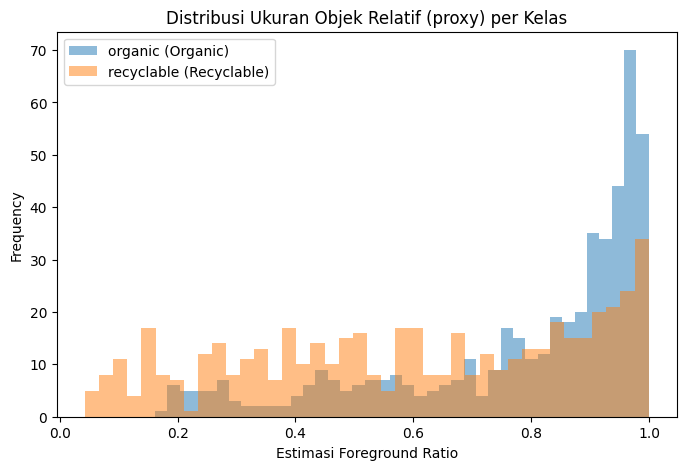

In [13]:
def estimate_foreground_ratio(img_path, threshold=30):
    with Image.open(img_path) as img:
        img_rgb = img.convert("RGB")
        arr = np.array(img_rgb).astype(int)
        h, w = arr.shape[:2]
        patch = 15
        corners = np.concatenate([
            arr[:patch, :patch].reshape(-1, 3), arr[:patch, -patch:].reshape(-1, 3),
            arr[-patch:, :patch].reshape(-1, 3), arr[-patch:, -patch:].reshape(-1, 3)
        ])
        bg_color = corners.mean(axis=0)
        diff = np.sqrt(((arr - bg_color) ** 2).sum(axis=2))
        foreground_mask = diff > threshold
        return foreground_mask.mean()

fg_results = []
for cls, files in sampled_files.items():
    for f in files:
        try:
            ratio = estimate_foreground_ratio(f)
            fg_results.append({"class": cls, "file": str(f), "foreground_ratio": ratio})
        except Exception:
            pass

df_fg = pd.DataFrame(fg_results)
print("=== Statistik Foreground Ratio (proxy ukuran objek) per Kelas ===")
print(df_fg.groupby("class")["foreground_ratio"].describe())

fig, ax = plt.subplots(figsize=(8, 5))
for cls in CLASS_FOLDERS:
    subset = df_fg[df_fg["class"] == cls]["foreground_ratio"]
    ax.hist(subset, bins=40, alpha=0.5, label=f"{cls} ({CLASS_LABELS.get(cls, cls)})")
ax.set_xlabel("Estimasi Foreground Ratio")
ax.set_ylabel("Frequency")
ax.set_title("Distribusi Ukuran Objek Relatif (proxy) per Kelas")
ax.legend()
plt.show()

In [14]:
import hashlib
from pathlib import Path
from collections import defaultdict

def compute_md5(file_path):
    hasher = hashlib.md5()
    with open(file_path, "rb") as f:
        for chunk in iter(lambda: f.read(8192), b""):
            hasher.update(chunk)
    return hasher.hexdigest()

hash_to_files = defaultdict(list)
all_files_to_check = []
for cls_dir in sorted(TRAIN_DIR.iterdir()):
    if not cls_dir.is_dir():
        continue
    for f in cls_dir.glob("*.*"):
        all_files_to_check.append((cls_dir.name, f))

print(f"Total file yang akan di-hash: {len(all_files_to_check)}")

for cls_name, f in all_files_to_check:
    try:
        h = compute_md5(f)
        hash_to_files[h].append((cls_name, f))
    except Exception as e:
        print(f"Gagal hash: {f} -> {e}")

duplicate_groups = {h: files for h, files in hash_to_files.items() if len(files) > 1}
print(f"\nJumlah grup duplikat (exact-hash match): {len(duplicate_groups)}")

cross_class_dupes = {}
within_class_dupes = {}
for h, files in duplicate_groups.items():
    classes_involved = set(cls for cls, f in files)
    if len(classes_involved) > 1:
        cross_class_dupes[h] = files
    else:
        within_class_dupes[h] = files

print(f"\n\U0001F6A9 Duplikat CROSS-CLASS (file sama, label beda): {len(cross_class_dupes)} grup")
print(f"Duplikat WITHIN-CLASS (file sama, label sama): {len(within_class_dupes)} grup")

if cross_class_dupes:
    print("\n=== DETAIL DUPLIKAT CROSS-CLASS ===")
    for h, files in list(cross_class_dupes.items())[:10]:
        print(f"\nHash: {h}")
        for cls, f in files:
            print(f"  [{cls}] {f.name}")

within_class_count = defaultdict(int)
for h, files in within_class_dupes.items():
    cls = files[0][0]
    within_class_count[cls] += len(files)

print("\n=== Jumlah file terlibat duplikat WITHIN-CLASS per kelas ===")
for cls, count in within_class_count.items():
    print(f"{cls}: {count} file")

Total file yang akan di-hash: 24705

Jumlah grup duplikat (exact-hash match): 326

🚩 Duplikat CROSS-CLASS (file sama, label beda): 1 grup
Duplikat WITHIN-CLASS (file sama, label sama): 325 grup

=== DETAIL DUPLIKAT CROSS-CLASS ===

Hash: 95bd2693fd68b87d40601c3002ebdf21
  [organic] organic_012716_photo.jpg
  [recyclable] recyclable_008879_photo.jpg

=== Jumlah file terlibat duplikat WITHIN-CLASS per kelas ===
organic: 630 file
recyclable: 20 file


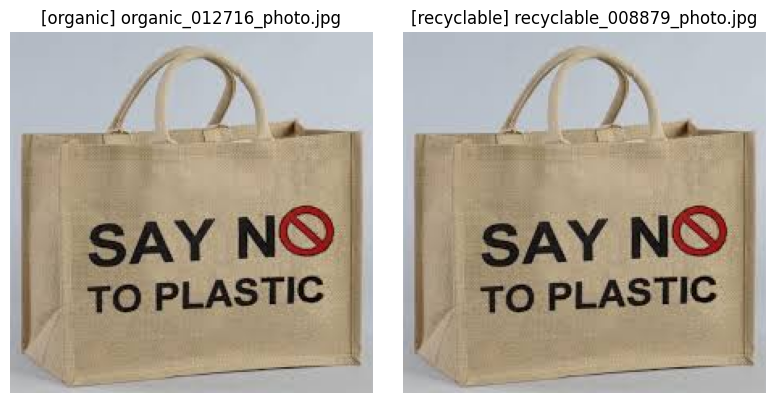

5 grup duplikat within-class terbesar:

Jumlah copy: 2
  [organic] organic_000184_photo.jpg
  [organic] organic_010375_photo.jpg

Jumlah copy: 2
  [organic] organic_004194_photo.jpg
  [organic] organic_008026_photo.jpg

Jumlah copy: 2
  [organic] organic_004407_photo.jpg
  [organic] organic_008218_photo.jpg

Jumlah copy: 2
  [organic] organic_004231_photo.jpg
  [organic] organic_008061_photo.jpg

Jumlah copy: 2
  [organic] organic_004204_photo.jpg
  [organic] organic_008142_photo.jpg


In [15]:
if cross_class_dupes:
    cross_pair = list(cross_class_dupes.values())[0]
    fig, axes = plt.subplots(1, 2, figsize=(8, 4))
    for i, (cls, f) in enumerate(cross_pair):
        img = Image.open(f)
        axes[i].imshow(img)
        axes[i].set_title(f"[{cls}] {f.name}")
        axes[i].axis("off")
    plt.tight_layout()
    plt.show()
else:
    print("Tidak ada duplikat cross-class yang ditemukan.")

if within_class_dupes:
    group_sizes = sorted([(len(files), h) for h, files in within_class_dupes.items()], reverse=True)
    print("5 grup duplikat within-class terbesar:")
    for size, h in group_sizes[:5]:
        files = within_class_dupes[h]
        print(f"\nJumlah copy: {size}")
        for cls, f in files:
            print(f"  [{cls}] {f.name}")
else:
    print("Tidak ada duplikat within-class yang ditemukan.")